

1.   Pengambilan data cuaca melalui API BMKG menggunakan kode wilayah masing-masing.
2. Proses pembersihan, validasi, dan penanganan missing value pada data time-series
3. Exploratory Data Analysis untuk mengidentifikasi pola temporal dan karakteristik cuaca lokal
4. Pengelompokan atau klasifikasi kondisi cuaca berdasarkan parameter meteorologi yang tersedia
5. Penyajian hasil analisis dan interpretasi secara sistematis serta reproducible



RUANG LINGKUP PENGERJAAN

Peserta wajib membangun pipeline end-to-end yang mencakup:

1. Data ingestion dari API
2. Parsing dan transformasi JSON
3. Data cleaning dan penanganan missing value
4. Exploratory Data Analysis (EDA)
5. Feature engineering manual
6. Model klasifikasi (Cerah, Berawan, Hujan)
7. Evaluasi menggunakan F1 Score

Parameter

*   utc_datetime : Waktu dalam UTC-YYYY-MM-DD HH:mm:ss
*   local_datetime : Waktu lokal-YYYY-MM-DD HH:mm:ss
*   t : Suhu Udara dalam °C
*   hu : Kelembapan Udara dalam %
* weather_desc : Kondisi Cuaca dalam Indonesia
* weather_desc_en : Kondisi Cuaca dalam English
* ws : Kecepatan Angin dalam km/jam
* wd : Arah Angin dari
* tcc - Tutupan Awan dalam %
* vs_text - Jarak Pandang dalam km
* analysis_date - Waktu produksi data prakiraan *]
* cuaca dalam UTC-YYYY-MM-DDTHH:mm:ss

1.
**Ingestion =** proses memasukkan / mengambil data dari suatu sumber ke dalam sistem kita.
Data ingestion adalah proses mengambil data dari sumber (API, database, file, dll) lalu membawanya masuk ke program untuk diproses.

# API

In [35]:
import requests
import json
import numpy as np #for numerical op
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, classification_report
from collections import Counter
from sklearn.svm import SVC
import pandas as pd




#### Data Ingestion

In [36]:
url = "https://api.bmkg.go.id/publik/prakiraan-cuaca?adm4=64.72.02.1001"

response = requests.get(url)
if response.status_code != 200:
  print("Gagal request API")
else:
  raw_data = response.json()
  with open("DATA_BAGUS.json", "w", encoding="utf-8") as f:
        json.dump(raw_data, f, indent=4, ensure_ascii=False)

# Print JSON rapi
print(json.dumps(raw_data, indent=4))

{
    "lokasi": {
        "adm1": "64",
        "adm2": "64.72",
        "adm3": "64.72.02",
        "adm4": "64.72.02.1001",
        "provinsi": "Kalimantan Timur",
        "kotkab": "Kota Samarinda",
        "kecamatan": "Samarinda Seberang",
        "desa": "Sungai Keledang",
        "lon": 117.1281493919,
        "lat": -0.5163767062,
        "timezone": "Asia/Makassar"
    },
    "data": [
        {
            "lokasi": {
                "adm1": "64",
                "adm2": "64.72",
                "adm3": "64.72.02",
                "adm4": "64.72.02.1001",
                "provinsi": "Kalimantan Timur",
                "kotkab": "Kota Samarinda",
                "kecamatan": "Samarinda Seberang",
                "desa": "Sungai Keledang",
                "lon": 117.1281493919,
                "lat": -0.5163767062,
                "timezone": "+0800",
                "type": "adm4"
            },
            "cuaca": [
                [
                    {
                   

#### Parsing dan transformasi JSON

In [37]:
if 'data' not in raw_data or not raw_data['data']:
    print("Data kosong")
else:
    cuaca_segments = raw_data['data'][0]['cuaca']
    flattened = []
    for segment in cuaca_segments:
        for item in segment:
              flattened.append({
                "utc_datetime": item.get("utc_datetime"),
                "local_datetime": item.get("local_datetime"),
                "suhu_c": item.get("t"),
                "kelembapan": item.get("hu"),
                "curah_hujan": item.get("tp"),
                "weather_desc": item.get("weather_desc"),
                "weather_desc_en": item.get("weather_desc_en"),
                "kecepatan_angin_kmh": item.get("ws"),
                "arah_angin": item.get("wd"),
                "tutupan_awan": item.get("tcc"),
                "jarak_pandang_km": item.get("vs_text"),
                "analysis_date": item.get("analysis_date")
            })
    df = pd.DataFrame(flattened)

df.head()

,utc_datetime,local_datetime,suhu_c,kelembapan,curah_hujan,weather_desc,weather_desc_en,kecepatan_angin_kmh,arah_angin,tutupan_awan,jarak_pandang_km,analysis_date
0,2026-07-16 14:00:00,2026-07-16 22:00:00,24,97,1.6,Hujan Ringan,Light Rain,6.0,W,61,< 6 km,2026-07-16T12:00:00
1,2026-07-16 17:00:00,2026-07-17 01:00:00,24,98,0.1,Cerah Berawan,Partly Cloudy,4.0,NW,78,> 10 km,2026-07-16T12:00:00
2,2026-07-16 20:00:00,2026-07-17 04:00:00,24,99,0.0,Berawan,Mostly Cloudy,3.9,NW,98,< 7 km,2026-07-16T12:00:00
3,2026-07-16 23:00:00,2026-07-17 07:00:00,25,94,0.0,Berawan,Mostly Cloudy,3.9,NW,100,< 10 km,2026-07-16T12:00:00
4,2026-07-17 02:00:00,2026-07-17 10:00:00,29,78,0.2,Cerah,Sunny,5.7,S,32,< 10 km,2026-07-16T12:00:00


In [38]:
csv_file = "DATA_BAGUS.csv"
df.to_csv(csv_file, index=False)

In [39]:
df = pd.read_csv('DATA_BAGUS.csv')

In [40]:
df.head()

,utc_datetime,local_datetime,suhu_c,kelembapan,curah_hujan,weather_desc,weather_desc_en,kecepatan_angin_kmh,arah_angin,tutupan_awan,jarak_pandang_km,analysis_date
0,2026-07-16 14:00:00,2026-07-16 22:00:00,24,97,1.6,Hujan Ringan,Light Rain,6.0,W,61,< 6 km,2026-07-16T12:00:00
1,2026-07-16 17:00:00,2026-07-17 01:00:00,24,98,0.1,Cerah Berawan,Partly Cloudy,4.0,NW,78,> 10 km,2026-07-16T12:00:00
2,2026-07-16 20:00:00,2026-07-17 04:00:00,24,99,0.0,Berawan,Mostly Cloudy,3.9,NW,98,< 7 km,2026-07-16T12:00:00
3,2026-07-16 23:00:00,2026-07-17 07:00:00,25,94,0.0,Berawan,Mostly Cloudy,3.9,NW,100,< 10 km,2026-07-16T12:00:00
4,2026-07-17 02:00:00,2026-07-17 10:00:00,29,78,0.2,Cerah,Sunny,5.7,S,32,< 10 km,2026-07-16T12:00:00


#Data cleaning dan penanganan missing value

In [41]:
#Copy Data
df_clean = df.copy()

In [42]:
#Cek struktur data
print("Shape:", df.shape)
print("\nInfo:")

df_clean.info()

Shape: (17, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   utc_datetime         17 non-null     object 
 1   local_datetime       17 non-null     object 
 2   suhu_c               17 non-null     int64  
 3   kelembapan           17 non-null     int64  
 4   curah_hujan          17 non-null     float64
 5   weather_desc         17 non-null     object 
 6   weather_desc_en      17 non-null     object 
 7   kecepatan_angin_kmh  17 non-null     float64
 8   arah_angin           17 non-null     object 
 9   tutupan_awan         17 non-null     int64  
 10  jarak_pandang_km     17 non-null     object 
 11  analysis_date        17 non-null     object 
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ KB


### Missing Value, Duplicate

In [43]:
#Cek missing value:
print("Missing value:")
df_clean.isnull().any()

Missing value:


,0
utc_datetime,False
local_datetime,False
suhu_c,False
kelembapan,False
curah_hujan,False
weather_desc,False
weather_desc_en,False
kecepatan_angin_kmh,False
arah_angin,False
tutupan_awan,False


In [44]:
#Hapus baris jika masih ada missing value tersisa
df_clean = df_clean.dropna()

In [45]:
print("Jumlah duplikat:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

print("Setelah: ", df_clean.duplicated().sum())

Jumlah duplikat: 0
Setelah:  0


In [46]:
df_clean = df_clean.drop(columns=["weather_desc_en", 'analysis_date', 'jarak_pandang_km', 'utc_datetime'])
df_clean.head()

,local_datetime,suhu_c,kelembapan,curah_hujan,weather_desc,kecepatan_angin_kmh,arah_angin,tutupan_awan
0,2026-07-16 22:00:00,24,97,1.6,Hujan Ringan,6.0,W,61
1,2026-07-17 01:00:00,24,98,0.1,Cerah Berawan,4.0,NW,78
2,2026-07-17 04:00:00,24,99,0.0,Berawan,3.9,NW,98
3,2026-07-17 07:00:00,25,94,0.0,Berawan,3.9,NW,100
4,2026-07-17 10:00:00,29,78,0.2,Cerah,5.7,S,32


#### Outliers

In [47]:
print("Sebelum: ")
df.describe()

Sebelum: 


,suhu_c,kelembapan,curah_hujan,kecepatan_angin_kmh,tutupan_awan
count,17.000000,17.000000,17.000000,17.000000,17.000000
mean,26.529412,87.705882,0.164706,4.964706,62.294118
std,2.527787,12.428620,0.380692,2.871398,33.366834
min,24.000000,63.000000,0.000000,1.300000,9.000000
25%,24.000000,78.000000,0.000000,2.800000,32.000000
50%,26.000000,94.000000,0.100000,4.000000,67.000000
75%,29.000000,97.000000,0.100000,6.000000,95.000000
max,31.000000,99.000000,1.600000,11.300000,100.000000


In [48]:
# Pembatasan
df_clean['kelembapan'] = df_clean['kelembapan'].clip(0, 100)
df_clean['tutupan_awan'] = df_clean['tutupan_awan'].clip(0, 100)

df_clean.describe()


,suhu_c,kelembapan,curah_hujan,kecepatan_angin_kmh,tutupan_awan
count,17.000000,17.000000,17.000000,17.000000,17.000000
mean,26.529412,87.705882,0.164706,4.964706,62.294118
std,2.527787,12.428620,0.380692,2.871398,33.366834
min,24.000000,63.000000,0.000000,1.300000,9.000000
25%,24.000000,78.000000,0.000000,2.800000,32.000000
50%,26.000000,94.000000,0.100000,4.000000,67.000000
75%,29.000000,97.000000,0.100000,6.000000,95.000000
max,31.000000,99.000000,1.600000,11.300000,100.000000


### Data Transform

In [49]:
# Mengubah kolom numerik agar benar-benar jadi angka
cols_to_numeric = ['suhu_c', 'kelembapan', 'curah_hujan', 'tutupan_awan', 'kecepatan_angin_kmh']
df_clean[cols_to_numeric] = df_clean[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

In [50]:
df_clean['local_datetime'] = pd.to_datetime(df_clean['local_datetime'])
df_clean['jam'] = df_clean['local_datetime'].dt.hour

df_clean.groupby('jam')['weather_desc'].value_counts()

jam  weather_desc 
1    Cerah Berawan    1
     Kabut/Asap       1
4    Berawan          1
     Kabut/Asap       1
7    Berawan          1
     Udara Kabur      1
10   Cerah            2
13   Berawan          1
     Cerah            1
16   Cerah            2
19   Cerah            1
     Cerah Berawan    1
22   Cerah            1
     Cerah Berawan    1
     Hujan Ringan     1
Name: count, dtype: int64

In [51]:
# Cek hasilnya
print(df.dtypes)
print("\nSetelah: ")
print(df_clean.dtypes)

utc_datetime            object
local_datetime          object
suhu_c                   int64
kelembapan               int64
curah_hujan            float64
weather_desc            object
weather_desc_en         object
kecepatan_angin_kmh    float64
arah_angin              object
tutupan_awan             int64
jarak_pandang_km        object
analysis_date           object
dtype: object

Setelah: 
local_datetime         datetime64[ns]
suhu_c                          int64
kelembapan                      int64
curah_hujan                   float64
weather_desc                   object
kecepatan_angin_kmh           float64
arah_angin                     object
tutupan_awan                    int64
jam                             int32
dtype: object


### ENCODING/DATA REPROCESSING

In [52]:
df['weather_desc'].unique()
df['weather_desc'].value_counts()

,count
weather_desc,
Cerah,7
Cerah Berawan,3
Berawan,3
Kabut/Asap,2
Hujan Ringan,1
Udara Kabur,1


In [53]:
def weather_mapping(desc):
    desc = str(desc).lower()

    if 'hujan' in desc or 'badai' in desc:
        return 2 # Hujan
    elif 'awan' in desc or 'mendung' in desc or 'kabut' in desc:
        return 1 # Berawan
    elif 'cerah' in desc:
        return 0 # Cerah
    else:
        return 1 #

# Terapkan
df_clean['weather_desc'] = df_clean['weather_desc'].apply(weather_mapping)

# Cek hasil
df_clean['weather_desc'].unique()
df_clean['weather_desc'].value_counts()

,count
weather_desc,
1,9
0,7
2,1


In [54]:
def kategori_waktu(jam):
    if 5 <= jam < 11:
        return "pagi"
    elif 11 <= jam < 15:
        return 'siang'
    elif 15 <= jam < 18:
        return 'sore'
    else:
        return 'malam'

df_clean['waktu_kategori'] = df_clean['jam'].apply(kategori_waktu)

In [55]:
df_clean.head()

,local_datetime,suhu_c,kelembapan,curah_hujan,weather_desc,kecepatan_angin_kmh,arah_angin,tutupan_awan,jam,waktu_kategori
0,2026-07-16 22:00:00,24,97,1.6,2,6.0,W,61,22,malam
1,2026-07-17 01:00:00,24,98,0.1,1,4.0,NW,78,1,malam
2,2026-07-17 04:00:00,24,99,0.0,1,3.9,NW,98,4,malam
3,2026-07-17 07:00:00,25,94,0.0,1,3.9,NW,100,7,pagi
4,2026-07-17 10:00:00,29,78,0.2,0,5.7,S,32,10,pagi


# EDA

In [56]:
print(df_clean.describe())

            local_datetime     suhu_c  kelembapan  curah_hujan  weather_desc  \
count                   17  17.000000   17.000000    17.000000     17.000000   
mean   2026-07-17 22:00:00  26.529412   87.705882     0.164706      0.647059   
min    2026-07-16 22:00:00  24.000000   63.000000     0.000000      0.000000   
25%    2026-07-17 10:00:00  24.000000   78.000000     0.000000      0.000000   
50%    2026-07-17 22:00:00  26.000000   94.000000     0.100000      1.000000   
75%    2026-07-18 10:00:00  29.000000   97.000000     0.100000      1.000000   
max    2026-07-18 22:00:00  31.000000   99.000000     1.600000      2.000000   
std                    NaN   2.527787   12.428620     0.380692      0.606339   

       kecepatan_angin_kmh  tutupan_awan        jam  
count            17.000000     17.000000  17.000000  
mean              4.964706     62.294118  12.117647  
min               1.300000      9.000000   1.000000  
25%               2.800000     32.000000   7.000000  
50%      

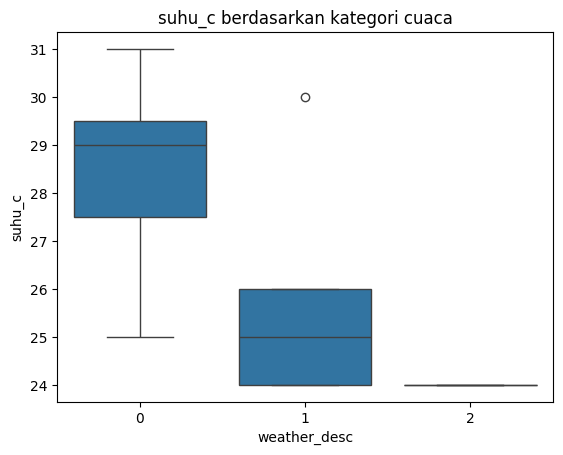

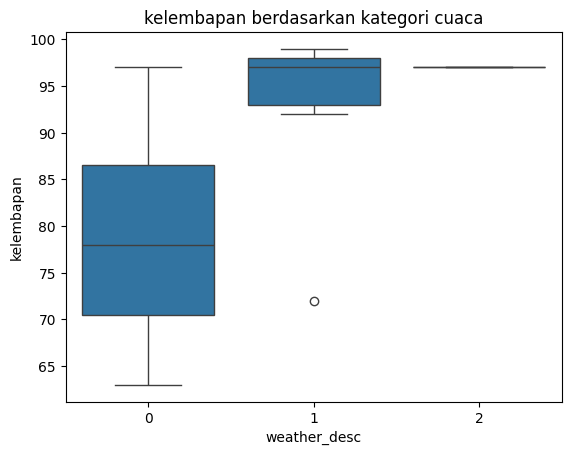

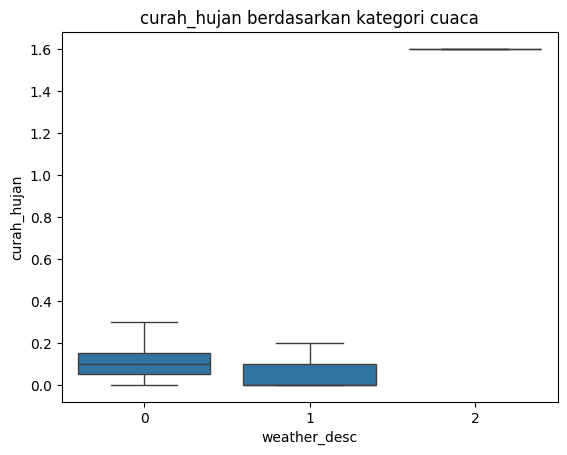

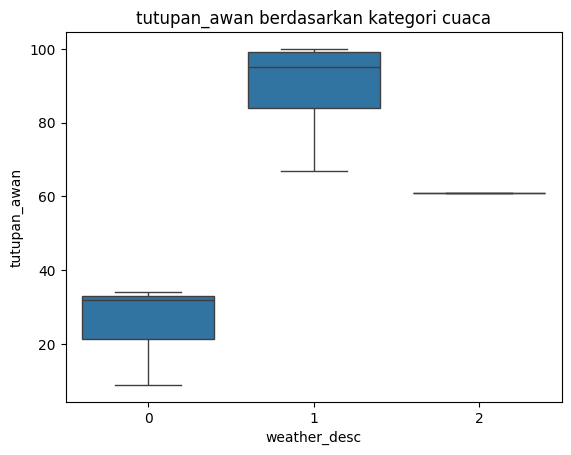

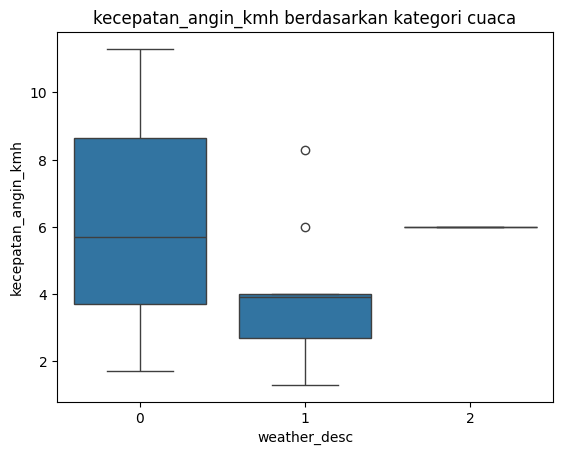

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

fitur = ['suhu_c', 'kelembapan', 'curah_hujan', 'tutupan_awan', 'kecepatan_angin_kmh']

for f in fitur:
    plt.figure()
    sns.boxplot(x='weather_desc', y=f, data=df_clean) # Changed 'label' to 'weather_desc'
    plt.title(f"{f} berdasarkan kategori cuaca")
    plt.show()

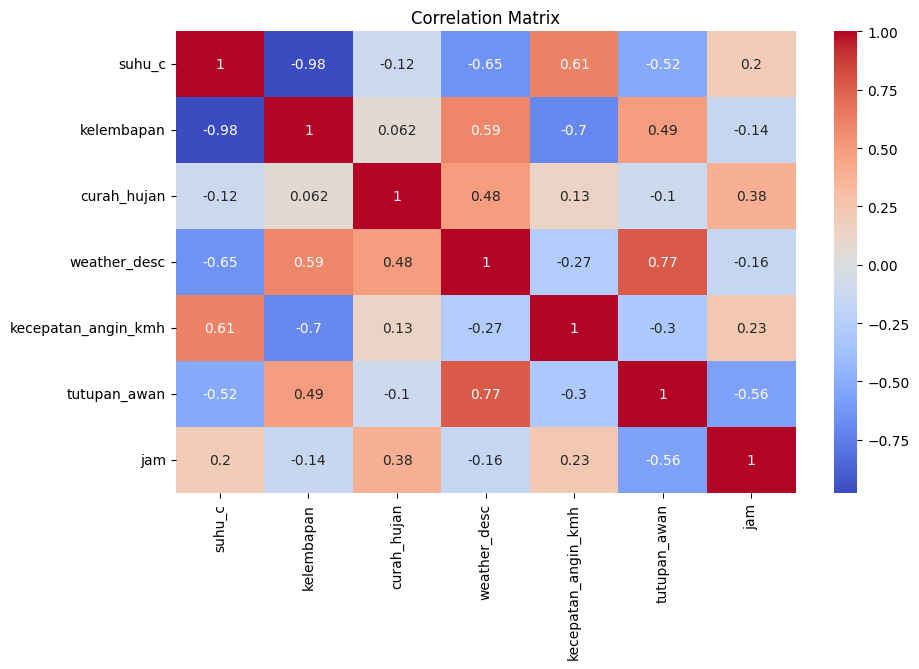

In [58]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

/tmp/ipykernel_1799/2020899806.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df_clean, x='suhu_c', y='kelembapan', hue='weather_desc',


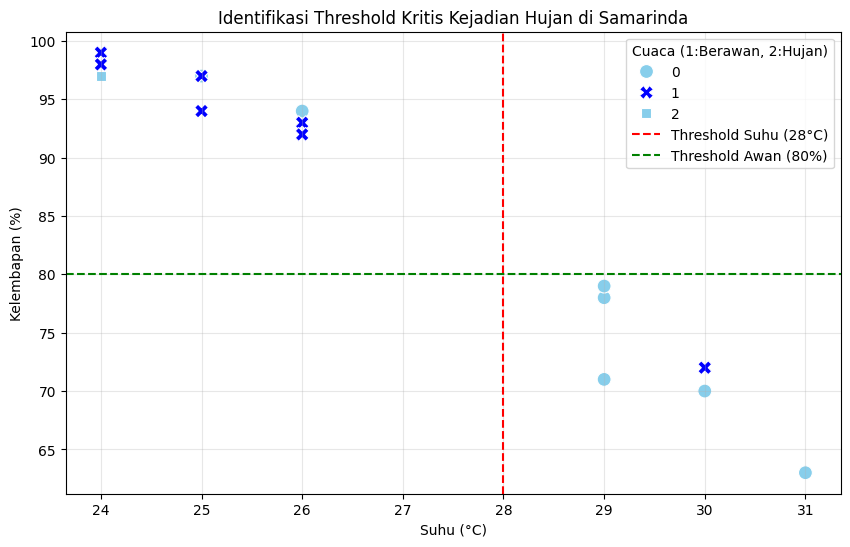

In [59]:
plt.figure(figsize=(10, 6))
# 1: Berawan, 2: Hujan
sns.scatterplot(data=df_clean, x='suhu_c', y='kelembapan', hue='weather_desc',
                palette=['skyblue', 'blue'], s=100, style='weather_desc')

plt.axvline(x=28, color='red', linestyle='--', label='Threshold Suhu (28°C)')
plt.axhline(y=80, color='green', linestyle='--', label='Threshold Awan (80%)')

plt.title('Identifikasi Threshold Kritis Kejadian Hujan di Samarinda')
plt.xlabel('Suhu (°C)')
plt.ylabel('Kelembapan (%)')
plt.legend(title='Cuaca (1:Berawan, 2:Hujan)')
plt.grid(True, alpha=0.3)
plt.show()

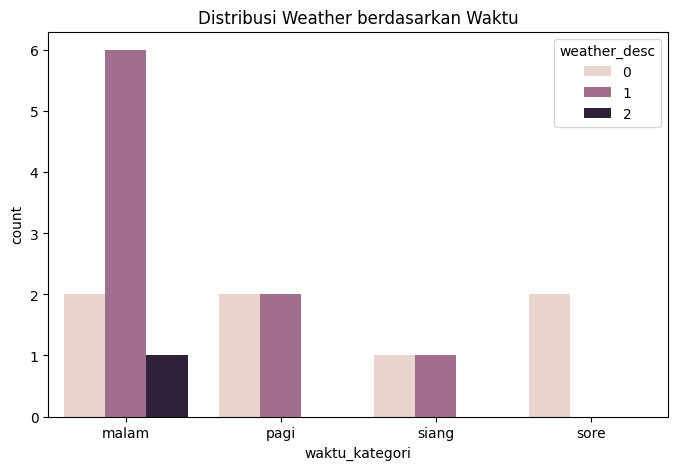

In [60]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='waktu_kategori', hue='weather_desc')
plt.title("Distribusi Weather berdasarkan Waktu")
plt.show()

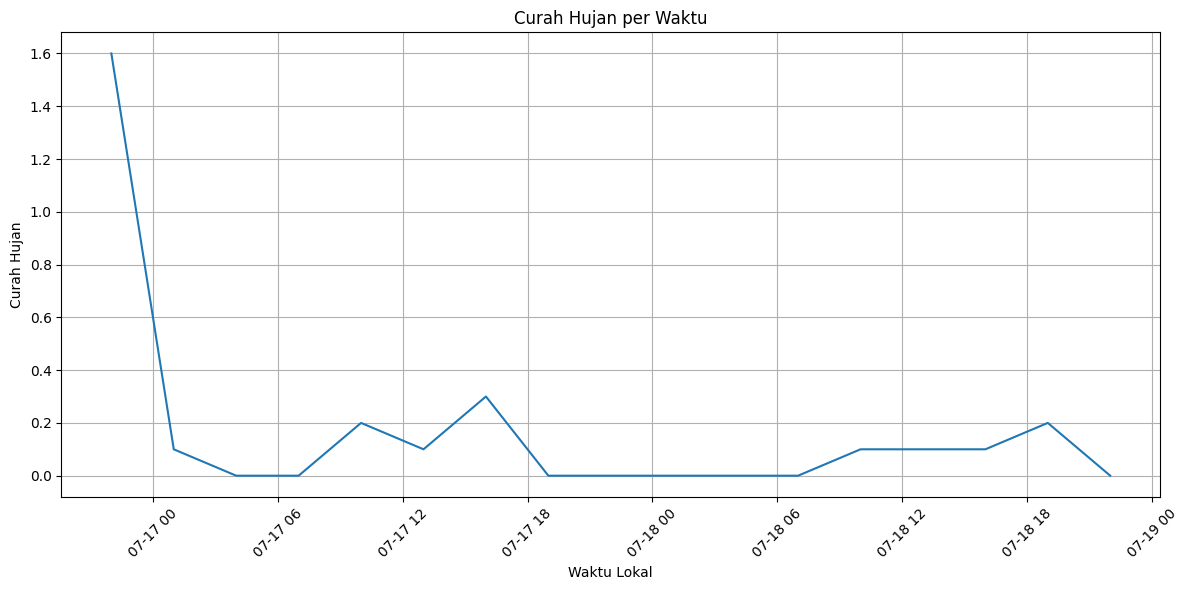

In [61]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='local_datetime', y='curah_hujan', data=df_clean)
plt.title('Curah Hujan per Waktu')
plt.xlabel('Waktu Lokal')
plt.ylabel('Curah Hujan')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# KLASIFIKASI

#### Feature Engineering


*   **[Titik embun ](https://)**: suhu saat udara tidak dapat lagi menampung semua uap air, sehingga kelembapan mulai mengembun.Semakin tinggi dew point, semakin tinggi kandungan uap air di udara (terasa lengket/lembap).
*   Item daftar


In [62]:
#Copy
df_final=df_clean.copy()

In [63]:
df_final['dew_point'] = df_final['suhu_c'] - ((100 - df_final['kelembapan']) / 5)
df_final['temp_gap'] = df_final['suhu_c'] - df_final['dew_point']

In [64]:
features = ['temp_gap', 'kelembapan', 'kecepatan_angin_kmh']

X = df_final[features]
y = df_final['weather_desc']

### TRAINING MODEL

In [65]:
df_final['weather_desc'].unique()
df_final['weather_desc'].value_counts()

,count
weather_desc,
1,9
0,7
2,1


#### Naive Bayes

In [66]:
from sklearn.naive_bayes import GaussianNB

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
from sklearn.naive_bayes import GaussianNB

# GaussianNB cocok untuk data kontinu (suhu, kelembapan, dll)
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [69]:
# 5. Prediksi dan Evaluasi (Sesuai Objektif Kompetisi: F1-Score)
y_pred = nb.predict(X_test)
f1_nb = f1_score(y_test, y_pred, average='macro')

print(f"Hasil F1-Score Naive Bayes: {f1_nb}")
print("\nLaporan Klasifikasi Lengkap:")
print(classification_report(y_test, y_pred, zero_division=0))

Hasil F1-Score Naive Bayes: 0.2222222222222222

Laporan Klasifikasi Lengkap:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.67      0.67      0.67         3
           2       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.22      0.22      0.22         4
weighted avg       0.50      0.50      0.50         4



In [70]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
cv_scores_nb = cross_val_score(nb, X, y, cv=skf, scoring='f1_macro')

print(f"Hasil F1-Score tiap Fold: {cv_scores_nb}")
print(f"Rata-rata F1-Score (K-Fold): {cv_scores_nb.mean():.4f}")

Hasil F1-Score tiap Fold: [0.39047619 0.87301587]
Rata-rata F1-Score (K-Fold): 0.6317


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


In [71]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_pred_nb = cross_val_predict(nb, X, y, cv=skf)
cm_nb = confusion_matrix(y, y_pred_nb)

print("Confusion Matrix NB:")
print(cm_nb)

Confusion Matrix NB:
[[5 2 0]
 [2 7 0]
 [0 1 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


In [72]:


print("\nClassification Report NB (Cross Validation):")
print(classification_report(y, y_pred_nb))


Classification Report NB (Cross Validation):
              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.70      0.78      0.74         9
           2       0.00      0.00      0.00         1

    accuracy                           0.71        17
   macro avg       0.47      0.50      0.48        17
weighted avg       0.66      0.71      0.68        17



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [73]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
scores_loo = cross_val_score(nb, X, y, cv=loo, scoring='f1_macro')
print("F1 tiap fold:", scores_loo)
print(f"Rata-rata F1 Macro (LOO): {scores_loo.mean()}")

F1 tiap fold: [0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
Rata-rata F1 Macro (LOO): 0.7058823529411765


In [74]:
y_pred_nb = cross_val_predict(nb, X, y, cv=loo)
cm_nb = confusion_matrix(y, y_pred_nb)

print("Confusion Matrix NB LOO:")
print(cm_nb)

Confusion Matrix NB LOO:
[[5 2 0]
 [2 7 0]
 [0 1 0]]


#### Random Forest


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

Train/Test Split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [78]:
rf = RandomForestClassifier(max_depth=3, min_samples_leaf=3, n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=3,
                       random_state=42)

In [79]:
# Prediksi TRAIN
y_train_pred = rf.predict(X_train)
# Prediksi TEST
y_test_pred = rf.predict(X_test)

In [80]:
# Hitung F1 Macro
f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_test = f1_score(y_test, y_test_pred, average='macro')

print("F1 Score TRAIN (Macro):", f1_train)
print("F1 Score TEST  (Macro):", f1_test)

F1 Score TRAIN (Macro): 0.8166666666666667
F1 Score TEST  (Macro): 0.47222222222222215


In [81]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.75      0.75      0.75         4
           2       0.00      0.00      0.00         1

    accuracy                           0.67         6
   macro avg       0.42      0.58      0.47         6
weighted avg       0.58      0.67      0.61         6



In [82]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

In [83]:
# Confusion matrix TRAIN
cm_train = confusion_matrix(y_train, y_train_pred)
# Confusion matrix TEST
cm_test = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix TRAIN:")
print(cm_train)
print("\nConfusion Matrix TEST:")
print(cm_test)

Confusion Matrix TRAIN:
[[4 2]
 [0 5]]

Confusion Matrix TEST:
[[1 0 0]
 [1 3 0]
 [0 1 0]]


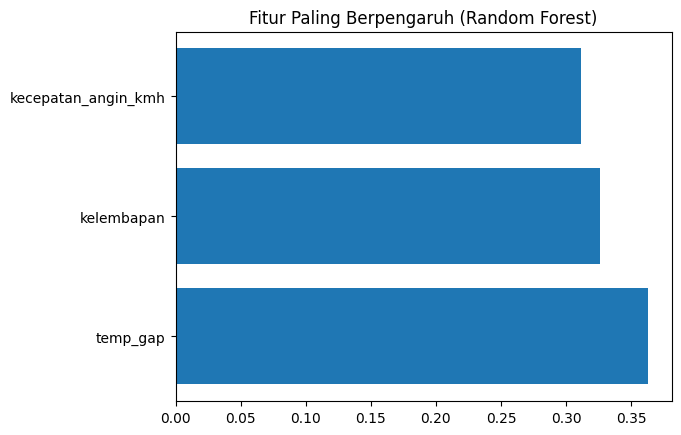

In [84]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
plt.barh(features, importances)
plt.title("Fitur Paling Berpengaruh (Random Forest)")
plt.show()

SMOTE

In [85]:
print("Sebelum SMOTE:")
print(y_train.value_counts())

Sebelum SMOTE:
weather_desc
0    6
1    5
Name: count, dtype: int64


In [86]:
sm = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [87]:
print("Sebelum SMOTE:")
print(y_res.value_counts())

Sebelum SMOTE:
weather_desc
0    6
1    6
Name: count, dtype: int64


In [88]:
rf_smote = RandomForestClassifier(max_depth=3, min_samples_leaf=3, n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_smote.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=3,
                       random_state=42)

In [89]:
y_train_pred_smote = rf_smote.predict(X_res)
y_test_pred_smote = rf_smote.predict(X_test)

In [90]:
f1_train_smote = f1_score(y_res, y_train_pred_smote, average='macro')
f1_test_smote = f1_score(y_test, y_test_pred_smote, average='macro')

print("F1 Score TRAIN (Macro):", f1_train_smote)
print("F1 Score TEST  (Macro):", f1_test_smote)

F1 Score TRAIN (Macro): 0.8333333333333334
F1 Score TEST  (Macro): 0.24444444444444446


In [91]:
# Confusion matrix TRAIN
cm_smote_train = confusion_matrix(y_res, y_train_pred_smote)
# Confusion matrix TEST
cm_smote_test = confusion_matrix(y_test, y_test_pred_smote)

print("Confusion Matrix TRAIN:")
print(cm_smote_train)
print("\nConfusion Matrix TEST:")
print(cm_test)

Confusion Matrix TRAIN:
[[5 1]
 [1 5]]

Confusion Matrix TEST:
[[1 0 0]
 [1 3 0]
 [0 1 0]]


In [92]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_smote, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       0.50      0.25      0.33         4
           2       0.00      0.00      0.00         1

    accuracy                           0.33         6
   macro avg       0.25      0.42      0.24         6
weighted avg       0.38      0.33      0.29         6



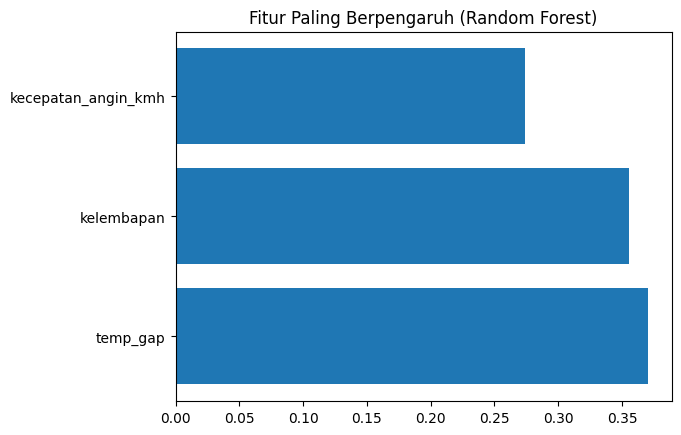

In [93]:
import matplotlib.pyplot as plt

importances = rf_smote.feature_importances_
plt.barh(features, importances)
plt.title("Fitur Paling Berpengaruh (Random Forest)")
plt.show()

Cross Validation

In [94]:
rf_cv = RandomForestClassifier(max_depth=3, min_samples_leaf=3, n_estimators=100, class_weight='balanced', random_state=42)

In [95]:
scores_cv = cross_val_score(rf, X, y, cv=3, scoring='f1_macro')
print("F1 tiap fold:", scores_cv)
print("Rata-rata:", scores_cv.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


F1 tiap fold: [0.61904762 0.48571429 0.22222222]
Rata-rata: 0.4423280423280424


In [96]:
y_pred_cv = cross_val_predict(rf, X, y, cv=2)
cm_cv = confusion_matrix(y, y_pred_cv)

print("Confusion Matrix Cross-Validation:")
print(cm_cv)
print("\nClassification Report (Cross Validation):")
print(classification_report(y, y_pred_cv, zero_division=0))

Confusion Matrix Cross-Validation:
[[5 2 0]
 [3 6 0]
 [0 1 0]]

Classification Report (Cross Validation):
              precision    recall  f1-score   support

           0       0.62      0.71      0.67         7
           1       0.67      0.67      0.67         9
           2       0.00      0.00      0.00         1

    accuracy                           0.65        17
   macro avg       0.43      0.46      0.44        17
weighted avg       0.61      0.65      0.63        17



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


##### KFold

In [97]:
from sklearn.model_selection import StratifiedKFold

# Pakai StratifiedKFold biar pembagian kelasnya rata
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [98]:
scores_kf = cross_val_score(rf, X, y, cv=skf)
print("F1 tiap fold:", scores_kf)
print("Rata-rata:", scores_kf.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


F1 tiap fold: [0.5        0.33333333 0.8       ]
Rata-rata: 0.5444444444444444


In [99]:
y_pred_cv_kf = cross_val_predict(rf, X, y, cv=skf)
cm_cv_kf = confusion_matrix(y, y_pred_cv_kf)

print("Confusion Matrix Cross-Validation:")
print(cm_cv_kf)
print("\nClassification Report (Cross Validation):")
print(classification_report(y, y_pred_cv_kf, zero_division=0))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Confusion Matrix Cross-Validation:
[[5 2 0]
 [4 4 1]
 [0 1 0]]

Classification Report (Cross Validation):
              precision    recall  f1-score   support

           0       0.56      0.71      0.62         7
           1       0.57      0.44      0.50         9
           2       0.00      0.00      0.00         1

    accuracy                           0.53        17
   macro avg       0.38      0.39      0.38        17
weighted avg       0.53      0.53      0.52        17



LOO

In [100]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
scores_loo = cross_val_score(rf, X, y, cv=loo, scoring='f1_macro')
print("F1 tiap fold:", scores_loo)
print(f"Rata-rata F1 Macro (LOO): {scores_loo.mean()}")

F1 tiap fold: [0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
Rata-rata F1 Macro (LOO): 0.6470588235294118


In [101]:
y_pred_cv_loo = cross_val_predict(rf, X, y, cv=loo)
cm_cv_loo = confusion_matrix(y, y_pred_cv)

print("Confusion Matrix Cross-Validation:")
print(cm_cv_loo)
print("\nClassification Report (Cross Validation):")
print(classification_report(y, y_pred_cv_loo, zero_division=0))

Confusion Matrix Cross-Validation:
[[5 2 0]
 [3 6 0]
 [0 1 0]]

Classification Report (Cross Validation):
              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.67      0.67      0.67         9
           2       0.00      0.00      0.00         1

    accuracy                           0.65        17
   macro avg       0.46      0.46      0.46        17
weighted avg       0.65      0.65      0.65        17



In [102]:
csv_output_file = "classification_results.csv"
df_final.to_csv(csv_output_file, index=False)
print(f"Hasil klasifikasi berhasil disimpan ke {csv_output_file}")

Hasil klasifikasi berhasil disimpan ke classification_results.csv


### FINAL